In [15]:
import pandas as pd

paper=pd.read_csv("round_state_paper.csv")
my=pd.read_csv("round_state.csv")

In [16]:

def split_into_rounds(data):
    # 1. Create a mask where the iteration resets to 1
    is_new_round = data['round'] == 1
    
    # 2. Use cumsum to create a unique ID for each block/round
    data['round_id'] = is_new_round.cumsum()
    
    # 3. Split into a dictionary of dataframes
    # Key = Round Number, Value = Dataframe for that round
    data_dict = {round_num: group for round_num, group in data.groupby('round_id')}
    
    # Optional: Clean up by removing the round_id column from the results
    for round_df in data_dict.values():
        round_df.drop(columns='round_id', inplace=True)

    return data_dict

paper_dict = split_into_rounds(paper)
my_dict = split_into_rounds(my)

In [19]:
print(len(paper_dict), len(my_dict))

# print(len(paper_dict[1]), len(paper_dict[2]))
for paper in paper_dict:
    print(len(paper_dict[paper]))
print()
for my in my_dict:
    print(len(my_dict[my]))

2 8
2203
2211

2326
2356
2159
2185
2020
2010
2215
2250


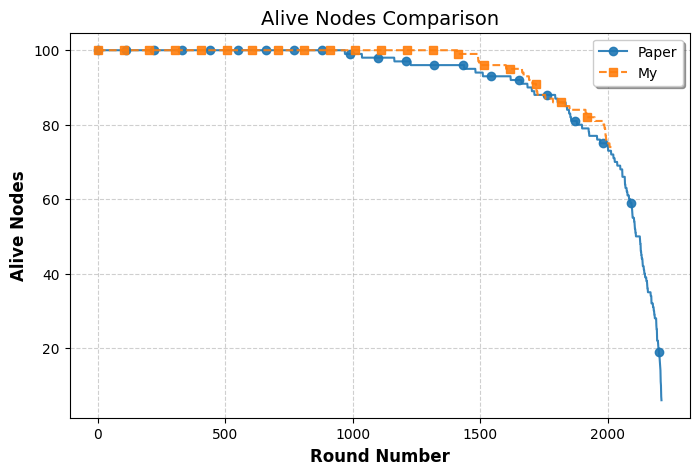

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5), dpi=100)




def plot_alive_nodes(df, name,color, style):
    marker_spacing = len(df) // 20
    plt.plot(
        df['round'], 
        df['alive_nodes'], 
        style, 
        markevery=marker_spacing,
        label=name,
        color=color,
        linewidth=1.5,
        markersize=6,
        alpha=0.9
    )


plot_alive_nodes(paper_dict[2], "Paper", "#1f77b4", "-o")
plot_alive_nodes(my_dict[5], "My", "#ff7f0e", "--s")

plt.xlabel('Round Number', fontsize=12, fontweight='bold')
plt.ylabel('Alive Nodes', fontsize=12, fontweight='bold')
plt.title('Alive Nodes Comparison', fontsize=14)
plt.legend(loc='best', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

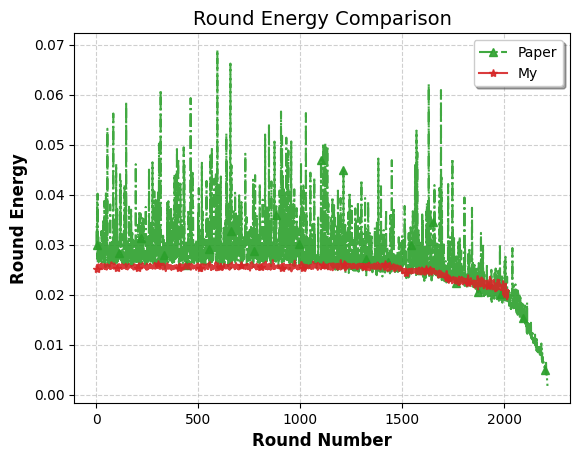

In [34]:

def plot_round_energy(df, name,color, style):
    marker_spacing = len(df) // 20
    plt.plot(
        df['round'], 
        df['round_energy'], 
        style, 
        markevery=marker_spacing,
        label=name,
        color=color,
        linewidth=1.5,
        markersize=6,
        alpha=0.9
    )


plot_round_energy(paper_dict[2], "Paper", "#2ca02c", "-.^")
plot_round_energy(my_dict[5], "My", "#d62728", "-*")

plt.xlabel('Round Number', fontsize=12, fontweight='bold')
plt.ylabel('Round Energy', fontsize=12, fontweight='bold')
plt.title('Round Energy Comparison', fontsize=14)
plt.legend(loc='best', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

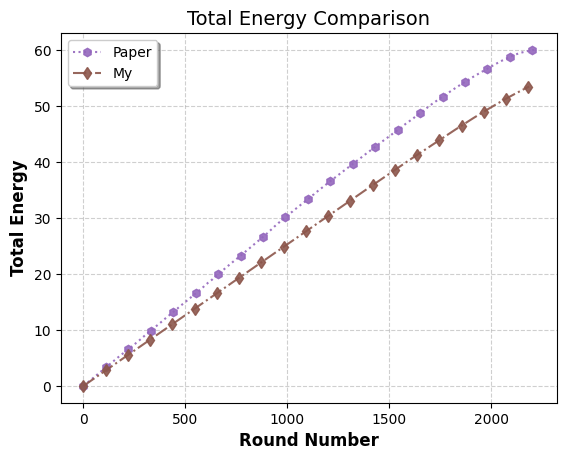

In [ ]:

def plot_total_energy(df, name,color, style):
    marker_spacing = len(df) // 20
    accumulated_energy = df['round_energy'].cumsum()
    plt.plot(
        df['round'], 
        accumulated_energy, 
        style, 
        markevery=marker_spacing,
        label=name,
        color=color,
        linewidth=1.5,
        markersize=6,
        alpha=0.9
    )


plot_total_energy(paper_dict[2], "Paper", "#9467bd", ":h")
plot_total_energy(my_dict[5], "My", "#8c564b", "-.d")

plt.xlabel('Round Number', fontsize=12, fontweight='bold')
plt.ylabel('Total Energy', fontsize=12, fontweight='bold')
plt.title('Total Energy Comparison', fontsize=14)
plt.legend(loc='best', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()